In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def chi2(T):
    p = T[0]; q = T[1]; r = T[2]; s = T[3]; t = T[4]; u = T[5]
    S = 0
    if p+q != 0:
        S += ((p-q)**2)/(p+q)
    if r+s != 0:
        S += ((r-s)**2)/(r+s)
    if t+u != 0:
        S += ((t-u)**2)/(t+u)
    return S

In [3]:
def EDOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    c = np.zeros((m,n,2))
    for i in range(m):
        T = TG[i]; X = chi2(T)
        for j in range(n):
            if x[j][i] == 0:
                Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 1:
                Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 2:
                Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 3:
                Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 4:
                Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 5:
                Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            
    #Step 2
    LSS = np.zeros(int(2**m)); LS_SIGN = np.zeros(m)
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = c[0][j][0]; LSJ[0][1] = c[0][j][1]
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + c[i][j][0]
                LSJ[i][2*k+1] = LSJ[i-1][k] + c[i][j][1]
        for i in range(int(2**m)):
            if LSS[i] < LSJ[m-1][i]:
                LSS[i] = LSJ[m-1][i]
                for l in range(m):
                    LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    LS = 0
    for i in range(int(2**m)):
        if LS < LSS[i]:
            LS = LSS[i]
            for l in range(m):
                LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    #print(LS_SIGN)
        
    #Step 3
    EDOLS = np.zeros((m,2)) #\hat{LS}^{i+-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                EDOLS[j][0] = max(EDOLS[j][0], LSS[i])
            else:
                EDOLS[j][1] = max(EDOLS[j][1], LSS[i])
    #print(EDOLS[:,0], EDOLS[:,1])
    
    #Step 4
    for i in range(m):
        if LS_SIGN[i] == 0:
            d = 1
        else:
            d = 0
        EDOLS[i][d] = 0
        for j in range(n):
            for s in range(int(2**m)):
                if int(s/(2**(m-1-i)))%2 == d:
                    t = 0
                    for l in range(m):
                        if l != i and EDOLS[l][int(s/(2**(m-1-l)))%2] != 0:
                            t += c[l][j][int(s/(2**(m-1-l)))%2]/EDOLS[l][int(s/(2**(m-1-l)))%2]
                    if t != 1:
                        EDOLS[i][d] = max(EDOLS[i][d], c[i][j][d]/(1-t))
    #print(EDOLS)
    return EDOLS[:,0], EDOLS[:,1]

In [4]:
def DOLS_chi2(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
            
    #Step 1
    MCP = np.zeros((m,6)); MCN = np.zeros((m,6)) #MaxChange
    for i in range(m):
        T = TG[i]
        X = chi2(T); MCP[i] = np.zeros(6); MCN[i] = np.zeros(6)
        if T[0] >= 1:
            Y = chi2([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = chi2([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
        if T[1] >= 1:
            Y = chi2([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = chi2([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
        if T[2] >= 1:
            Y = chi2([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = chi2([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
        if T[3] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
        if T[4] >= 1:
            Y = chi2([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = chi2([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
        if T[5] >= 1:
            Y = chi2([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = chi2([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
    
    #Step 2
    LSS = np.zeros(int(2**m))
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = MCP[0][int(x[j][0])]; LSJ[0][1] = MCN[0][int(x[j][0])]
        #print(LSJ[0],LSJ[1])
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + MCP[i][int(x[j][i])]
                LSJ[i][2*k+1] = LSJ[i-1][k] + MCN[i][int(x[j][i])]
        #print(LSJ)
        for i in range(int(2**m)):
            LSS[i] = max(LSS[i],LSJ[m-1][i])    
        #print(LSS)
        
    #Step 3
    DOLSP = np.zeros(m) #LS^{i+}
    DOLSN = np.zeros(m) #LS^{i-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                DOLSP[j] = max(DOLSP[j], LSS[i])
            else:
                DOLSN[j] = max(DOLSN[j], LSS[i])
    
    return DOLSP, DOLSN

In [5]:
def NeighboringY(x,n,m):
    y = np.ones((n,int(2**m),n,m))
    for i in range(n):
        for j in range(int(2**m)):
            for k in range(m):
                l = int(j/(2**(m-1-k)))%2
                if x[i][k] == 0:
                    if l == 0:
                        y[i][j][i][k] = 2
                    else:
                        y[i][j][i][k] = 4
                if x[i][k] == 1:
                    if l == 0:
                        y[i][j][i][k] = 3
                    else:
                        y[i][j][i][k] = 5
                if x[i][k] == 2:
                    if l == 0:
                        y[i][j][i][k] = 0
                    else:
                        y[i][j][i][k] = 4
                if x[i][k] == 3:
                    if l == 0:
                        y[i][j][i][k] = 1
                    else:
                        y[i][j][i][k] = 5
                if x[i][k] == 4:
                    if l == 0:
                        y[i][j][i][k] = 0
                    else:
                        y[i][j][i][k] = 2
                if x[i][k] == 5:
                    if l == 0:
                        y[i][j][i][k] = 1
                    else:
                        y[i][j][i][k] = 3
    return y

def EDOSS_chi2(x,n,m): #Th.4
    EDOSSP = np.zeros((m,4)); EDOSSN = np.zeros((m,4)); kk = [2,3,4,6]
    for i in range(m):
        EDOLSP, EDOLSN = EDOLS_chi2(x,n,m)
        for k in range(4):
            EDOSSP[i][k] = max([EDOLSP[i], EDOLSN[i]*math.exp(-2*(20/(2*(kk[k]-1))))])
            EDOSSN[i][k] = max([EDOLSN[i], EDOLSP[i]*math.exp(-2*(20/(2*(kk[k]-1))))])
    y = NeighboringY(x,n,m)
    t = np.zeros((m,4))
    for j in range(n):
        for i in range(int(2**m)):
            DOLSP, DOLSN = DOLS_chi2(y[j][i],n,m)
            for l in range(m):
                for k in range(4):
                    t[l][k] = max([t[l][k],max([DOLSP[l],DOLSN[l]])*math.exp(-(20/(2*(kk[k]-1))))])
            yy = NeighboringY(y[j][i],n,m)
            for jj in range(n):
                for ii in range(int(2**m)):
                    DOLSP, DOLSN = DOLS_chi2(yy[jj][ii],n,m)
                    for l in range(m):
                        for k in range(4):
                            t[l][k] = max([t[l][k],max([DOLSP[l],DOLSN[l]])*math.exp(-2*(20/(2*(kk[k]-1))))])
    for i in range(m):
        for k in range(4):
            EDOSSP[i][k] = max([EDOSSP[i][k],t[i][k]])
            EDOSSN[i][k] = max([EDOSSN[i][k],t[i][k]])
    return EDOSSP, EDOSSN

In [6]:
def EDOSS_chi2_test(n,m): #Enhanced DOSS #epsilon = 20*m
    GS = (4*n/(n+2))*m
    while(1):
        x = np.zeros((n,m))
        for j in range(m):
            x[:,j] = np.ones(n)
            case = random.sample(range(n), k=int(n/2))
            for i in range(int(n/2)):
                r = random.random()
                if r < 1/3:
                    x[case[i]][j] = 0
                elif r < 2/3:
                    x[case[i]][j] = 2
                else:
                    x[case[i]][j] = 4
            for i in range(n):
                if x[i][j] == 1:
                    r = random.random()
                    if r < 1/3:
                        x[i][j] = 1
                    elif r < 2/3:
                        x[i][j] = 3
                    else:
                        x[i][j] = 5
        EDOLSP, EDOLSN = EDOLS_chi2(x,n,m)
        f = 0
        for i in range(m):
            if EDOLSP[i] == 0 or EDOLSN[i] == 0:
                f = 1
            elif GS/max([EDOLSP[i],EDOLSN[i]]) >= math.exp(2):
                f = 1
        if f == 0:
            EDOSSP, EDOSSN = EDOSS_chi2(x,n,m)
            return EDOSSP, EDOSSN

In [7]:
def h2(z,l):
    return np.sqrt(l)/(math.pi*(z**2+l))

def h3(z,l):
    return (3*np.sqrt(3)*(l**(2/3)))/(4*math.pi*(math.fabs(z)**3+l))

def h4(z,l):
    return (np.sqrt(2)*(l**(3/4)))/(math.pi*(z**4+l))

def h6(z,l):
    return (3*(l**(5/6)))/(2*math.pi*(z**6+l))

def cdf(x,h,l):
    g = lambda z: h(z,l)
    return integrate.quad(g,-oo,x)

def noise(h,l,d): # using inverse transform sampling
    r = np.random.rand()
    q = 1000; z = 10
    for i in range(-50,50):
        if math.fabs(r - cdf(i/5,h,l)[0]) > q:
            z = (i-1)/5
            break
        else:
            q = min(q, math.fabs(r - cdf(i/5,h,l)[0]))
    if d == 0:
        return math.fabs(z)
    elif d == 1:
        return -math.fabs(z)
    
def alpha(k,l,m): #epsilon = 20*m
    return ((l**(1/k))*(20*m))/(2*((k-1)**((k-1)/k)))

In [8]:
def accuracy(n,m,EDOSSP,EDOSSN): # epsilon = 20*m
    acc = np.zeros((6,4))
    l = [0.5,1,2,3,4,5]
    SS = np.zeros((m,4)); d = np.zeros(m)
    
    for j in range(20):
        for i in range(6):
            for t in range(m):
                if random.random()<0.5:
                    d[t] = 0; SS[t][0] = EDOSSP[t][0]; SS[t][1] = EDOSSP[t][1]; SS[t][2] = EDOSSP[t][2]; SS[t][3] = EDOSSP[t][3] 
                else:
                    d[t] = 1; SS[t][0] = EDOSSN[t][0]; SS[t][1] = EDOSSN[t][1]; SS[t][2] = EDOSSN[t][2]; SS[t][3] = EDOSSN[t][3] 
                acc[i][0] += math.fabs((SS[t][0]/alpha(2,l[i],m))*noise(h2,l[i],d[t]))
                acc[i][1] += math.fabs((SS[t][1]/alpha(3,l[i],m))*noise(h3,l[i],d[t]))
                acc[i][2] += math.fabs((SS[t][2]/alpha(4,l[i],m))*noise(h4,l[i],d[t]))
                acc[i][3] += math.fabs((SS[t][3]/alpha(6,l[i],m))*noise(h6,l[i],d[t]))
    return acc/(m*20)

[[0.17451881 0.05117367 0.09670097 0.13124422]
 [0.12816132 0.08322016 0.09813284 0.13225218]
 [0.08808243 0.08876357 0.05513015 0.11964963]
 [0.08590822 0.06457323 0.08168428 0.10803977]
 [0.10914918 0.08224216 0.0782286  0.13088993]
 [0.07445915 0.05375359 0.07780787 0.09804943]]
[[0.13713454 0.06293812 0.08257925 0.09783744]
 [0.09014277 0.07436202 0.08775403 0.12701387]
 [0.09593026 0.07602377 0.08172808 0.11705192]
 [0.10653462 0.06464083 0.10610445 0.12331755]
 [0.09657178 0.08278846 0.08477247 0.13933923]
 [0.09538269 0.07218198 0.07549041 0.11887144]]
[[0.09278075 0.10986439 0.06913204 0.12553878]
 [0.12157849 0.05486779 0.08026353 0.11708783]
 [0.08108021 0.08447317 0.11011594 0.13669351]
 [0.09481269 0.06605532 0.1048502  0.12523326]
 [0.08461557 0.05850059 0.10188155 0.11046199]
 [0.097242   0.07099098 0.09389999 0.07777858]]
[[0.09514179 0.07133691 0.09272582 0.1163846 ]
 [0.07526961 0.07899558 0.09197991 0.13495009]
 [0.12240455 0.08654798 0.08752296 0.11752272]
 [0.109719

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


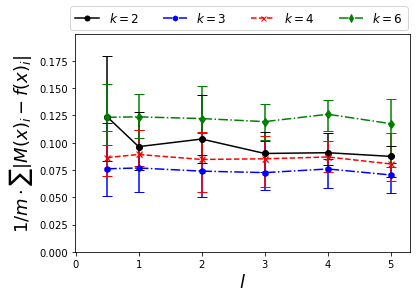

In [9]:
n = 150; m = 2

acc = np.zeros((6,4))
max_acc = np.zeros((6,4)); min_acc = np.ones((6,4))
sum_acc = np.zeros((6,4))

EDOSSP, EDOSSN = EDOSS_chi2_test(n,m)

jj = 10
for j in range(jj):
    acc = accuracy(n,m,EDOSSP,EDOSSN)
    for i in range(6):
        for k in range(4):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/jj

y_err = np.zeros((2,6,4))
for k in range(4):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

l = [0.5,1,2,3,4,5]

print(acc)
fig = plt.figure()
plt.ylim(0, max(max_acc[i][j] for i in range(6) for j in range(4))+0.02)
plt.xlim(-0.01, 5.3)
plt.errorbar(l, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='o', ecolor='black', markeredgecolor = "black", color='black')
plt.plot(l, acc[:,0], marker="o", markersize=5, color = "black", linestyle = "-", label = "$k = 2$")
plt.errorbar(l, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='h', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.plot(l, acc[:,1], marker="h", markersize=5, color = "blue", linestyle = "dashdot", label = "$k = 3$")
plt.errorbar(l, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='x', ecolor='red', markeredgecolor = "red", color='red')
plt.plot(l, acc[:,2], marker="x", markersize=5, color = "red", linestyle = "--", label = "$k = 4$")
plt.errorbar(l, acc[:,3], yerr = y_err[:,:,3], capsize=5, fmt='d', ecolor='green', markeredgecolor = "green", color='green')
plt.plot(l, acc[:,3], marker="d", markersize=5, color = "green", linestyle = "dashdot", label = "$k = 6$")
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=4, fontsize=12)
plt.xlabel("$l$", fontsize = 18)
plt.ylabel("$1/m \cdot \sum |M(x)_i - f(x)_i|$", fontsize = 18)
fig.savefig("Accuracy_chi2_kl_m=2.png")
fig.savefig("figs/Accuracy_chi2_kl_m=2.eps", bbox_inches="tight", pad_inches=0.05)